In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.boston_housing.load_data()

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
                 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)


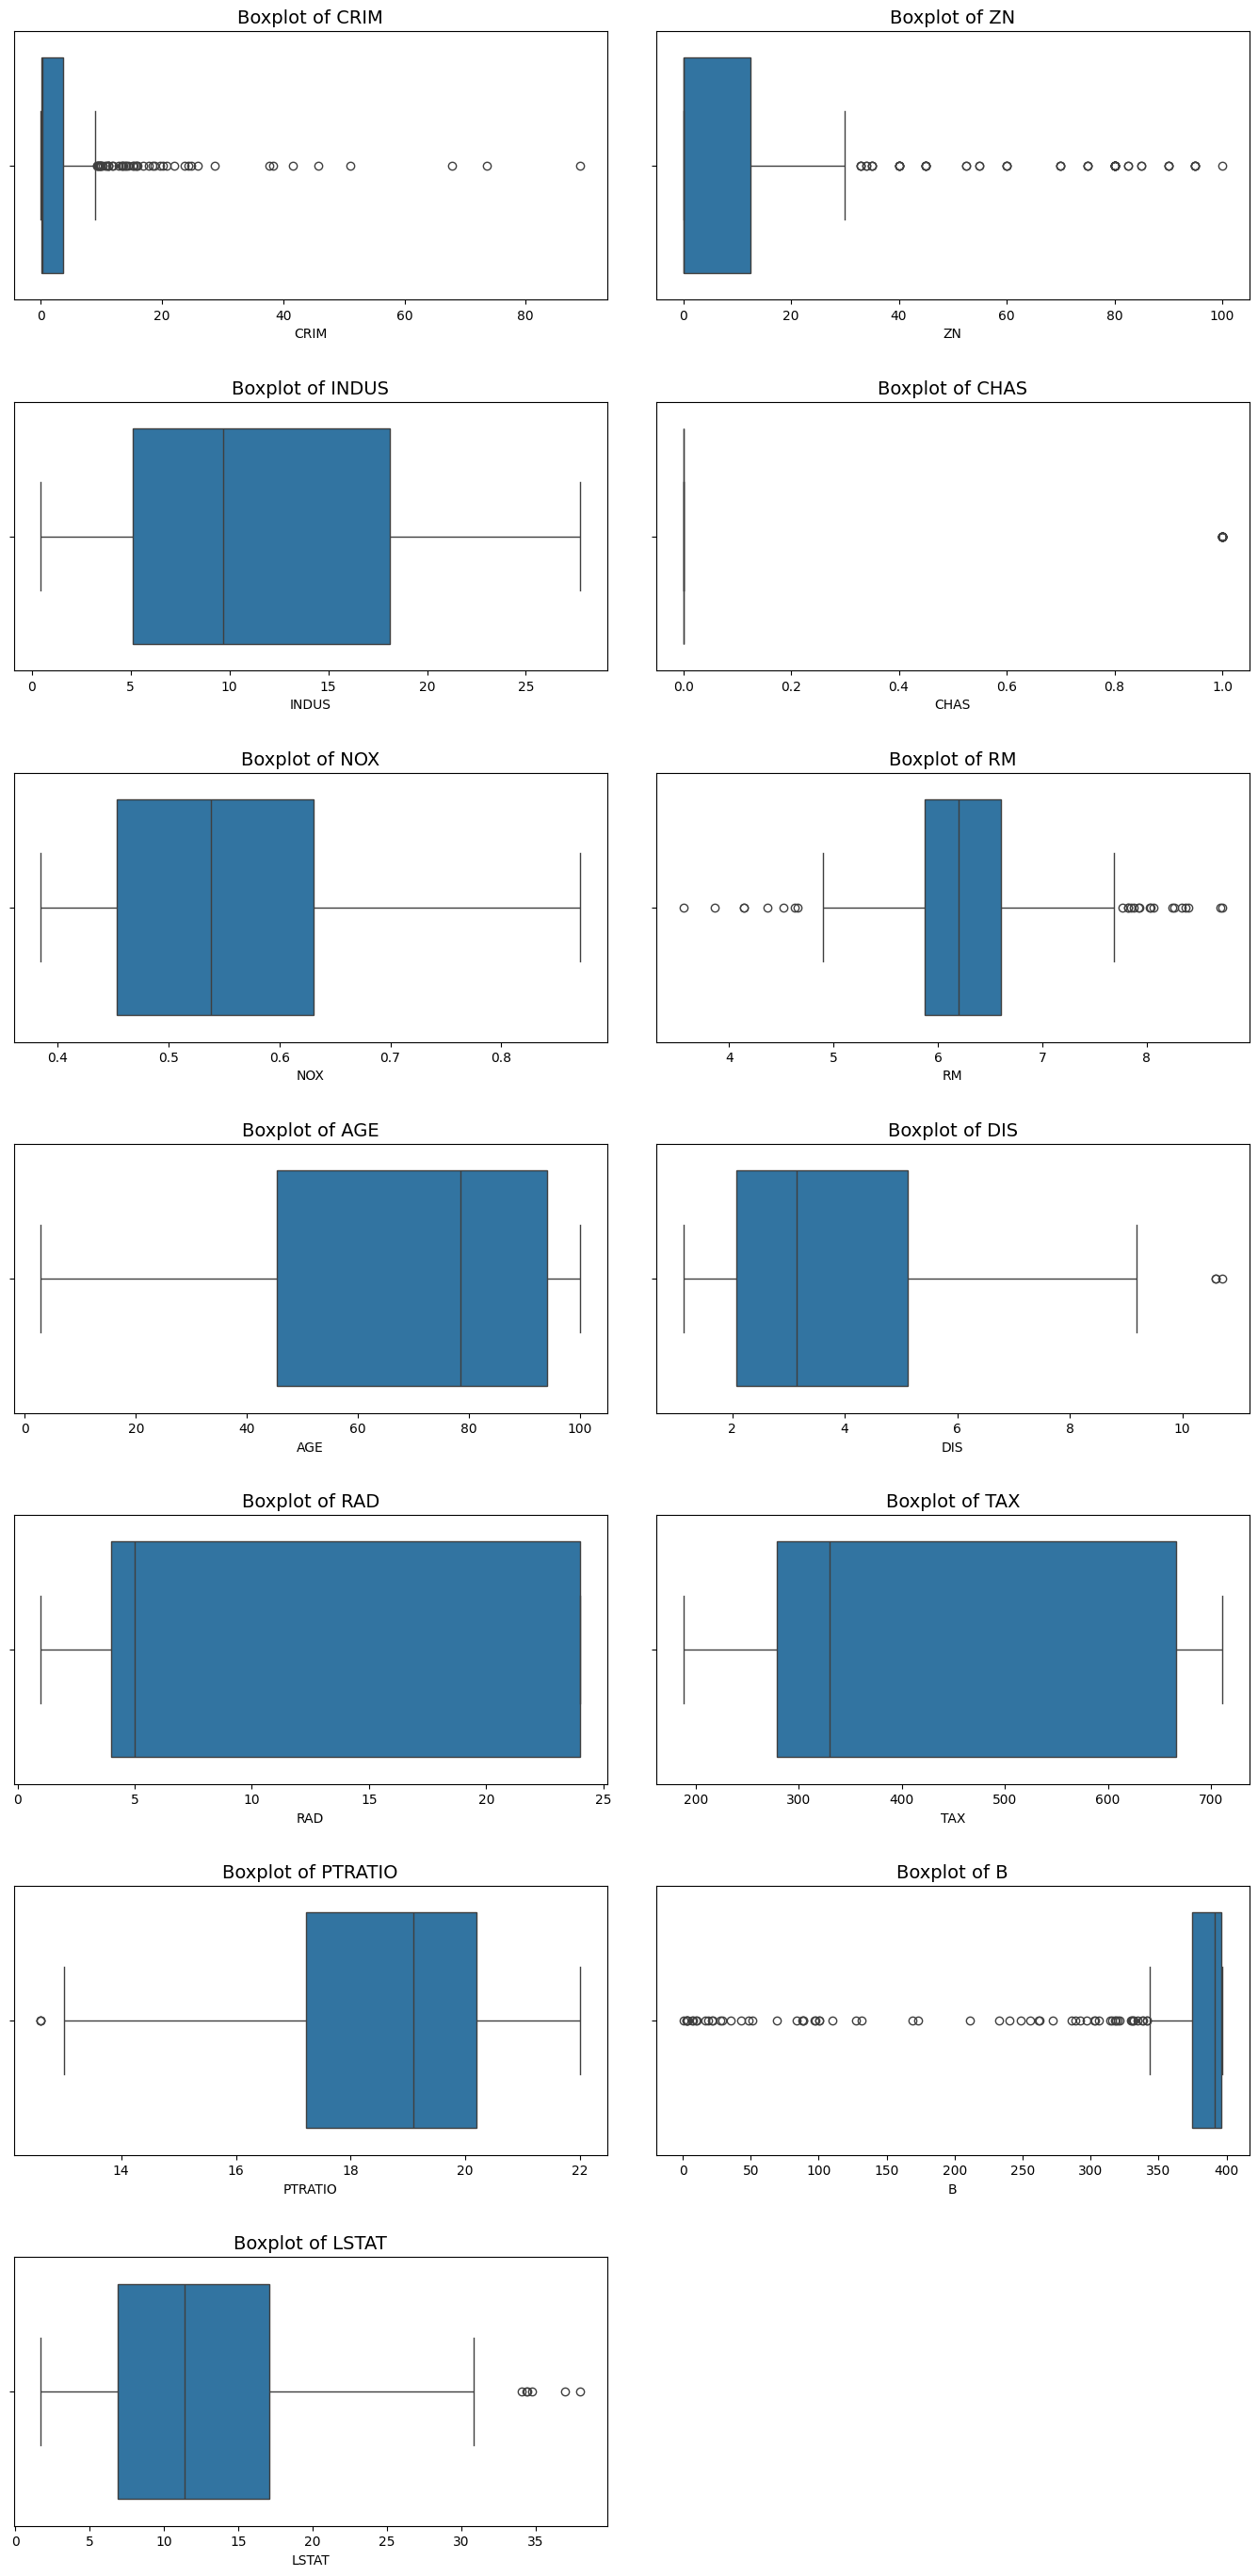

In [3]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(14, 4 * 7))
axes = axes.flatten()

for i, feat in enumerate(X_train.columns):
    ax = axes[i]
    sns.boxplot(data=X_train, x=feat, ax=ax)
    ax.set_title(f'Boxplot of {feat}', fontsize=14)

for i in range(len(X_train.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=3.0)
plt.show()


In [4]:
for feat in X_train.columns:
    p1 = X_train[feat].quantile(0.01)
    p99 = X_train[feat].quantile(0.99)

    X_train[feat] = np.clip(X_train[feat], p1, p99)
    X_test[feat] = np.clip(X_test[feat], p1, p99)


In [5]:
qt = QuantileTransformer(output_distribution='normal', n_quantiles=X_train.shape[0])
qt.fit(X_train)
X_train_scaled = pd.DataFrame(qt.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(qt.transform(X_test), columns=X_test.columns, index=X_test.index)


In [6]:
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 539.8498 - mae: 21.3136 - val_loss: 504.8666 - val_mae: 20.2179
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 406.4225 - mae: 17.5699 - val_loss: 346.7029 - val_mae: 15.7820
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 258.3546 - mae: 12.7291 - val_loss: 195.0496 - val_mae: 10.5388
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 154.8828 - mae: 9.5761 - val_loss: 120.7884 - val_mae: 7.5772
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 126.1682 - mae: 8.5440 - val_loss: 92.6983 - val_mae: 6.3315
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 85.2165 - mae: 6.4161 - val_loss: 84.1602 - val_mae: 6.1385
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 77.0797 - mae: 6.4952 - val_loss: 71.0413 - val_mae: 5.7830
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 78.8978 - mae: 6.6116 - val_loss: 57.5490 - val_mae: 5.1977
Epoch 9/200
11/11 ━━━━━━━

In [8]:
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred = model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

train_mae = history.history['mae'][-1]
val_mae = history.history['val_mae'][-1]

print(f"Training MAE: {train_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test MSE: {mse:.2f}")
print(f"Test R² Score: {r2 * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Training MAE: 4.19
Validation MAE: 3.12
Test MAE: 3.89
Test MSE: 29.61
Test R² Score: 64.43%


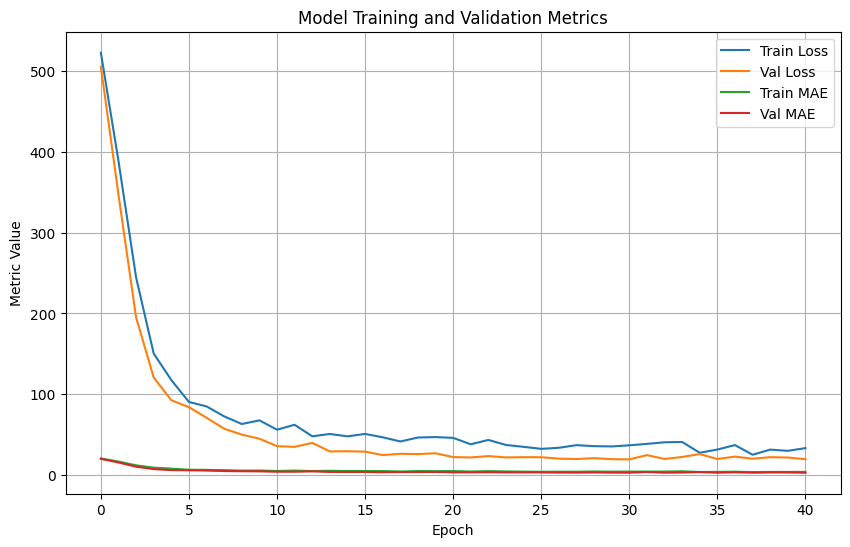

In [9]:
pd.DataFrame(history.history)[['loss', 'val_loss', 'mae', 'val_mae']].plot(figsize=(10, 6))
plt.grid(True)
plt.title('Model Training and Validation Metrics')
plt.ylabel('Metric Value')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Val Loss', 'Train MAE', 'Val MAE'])
plt.show()

In [10]:
# model.save("boston_housing_model.h5")
# To load later: model = tf.keras.models.load_model("boston_housing_model.h5")
